# Bayesian Linear Regression

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain how Bayesian regression extends the frequentist OLS framework from Module 06 by placing **posterior distributions** over regression coefficients instead of point estimates.
2. Write down the full **Bayesian linear model** and justify the choice of priors for intercept, slopes, and noise.
3. Build a Bayesian linear regression in **PyMC**, sample from the posterior, and interpret trace plots, posterior summaries, and credible intervals.
4. Perform **prior predictive checks** and **posterior predictive checks** to assess model quality.
5. Explain the difference between **credible intervals** (Bayesian) and **confidence intervals** (frequentist) and why the Bayesian interpretation is often more intuitive.
6. Compare Bayesian posterior means with OLS estimates and explain when and why they diverge.

## Prerequisites

- [Module 06 — Simple and multiple linear regression (OLS)](../06_linear_models/01_simple_linear_regression.ipynb)
- [Module 07 — Bayes' theorem, priors, MCMC](../07_bayesian_inference/01_bayes_theorem_revisited.ipynb)
- [Module 04 — Confidence intervals](../04_estimation/04_confidence_intervals.ipynb)

In [ ]:
import sys, os, shutil
from pathlib import Path

# Fix PyTensor C-compilation issue on Windows (conda doesn't ship g++)
os.environ["PYTENSOR_FLAGS"] = "device=cpu,floatX=float64,cxx="

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim pymc arviz statsmodels ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()

# ── PyMC / ArviZ ──
HAS_PYMC = False
try:
    import pymc as pm
    import arviz as az

    HAS_PYMC = True
    print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")
except Exception as e:
    print(f"PyMC not available: {type(e).__name__}: {e}")

# ── statsmodels (for OLS comparison) ──
try:
    import statsmodels.api as sm

    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("statsmodels not available — OLS comparison cells will be skipped.")


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
c:\Users\Alexander_Timmer\Miniconda3\envs\amstats\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


PyMC 5.28.2, ArviZ 0.23.4


---

## 1. From Frequentist to Bayesian Regression

In Module 06 we fitted linear models by **ordinary least squares (OLS)**.  Given data $(\mathbf{X}, \mathbf{y})$, we obtained point estimates $\hat{\boldsymbol{\beta}}$ and standard errors $\operatorname{SE}(\hat{\beta}_j)$.  These are powerful tools, but they come with limitations:

- **Point estimates only.** OLS gives a single "best" value for each coefficient.  We get standard errors and confidence intervals, but these are properties of a *hypothetical repeated-sampling procedure*, not direct probability statements about the parameters.
- **Confidence interval interpretation.** The 95% CI for $\beta_1$ does **not** mean "there is a 95% probability that $\beta_1$ lies in this interval."  It means: if we repeated the experiment many times, 95% of the constructed intervals would contain the true $\beta_1$.  This is correct but unintuitive (and widely misunderstood).
- **No mechanism for prior information.** If we know from physics that a coefficient should be positive, or from a previous study that it is likely near 2.5, OLS has no formal way to incorporate this knowledge.

### What Bayesian regression gives us

Bayesian regression replaces the point estimate $\hat{\boldsymbol{\beta}}$ with a **full posterior distribution** $P(\boldsymbol{\beta} \mid \mathbf{y}, \mathbf{X})$.  This distribution tells us:

| Question                                         | Bayesian answer                                         |
|--------------------------------------------------|---------------------------------------------------------|
| What is the most likely value of $\beta_1$?      | Posterior mean or mode                                  |
| How uncertain am I about $\beta_1$?              | Width of the posterior                                  |
| Is there a 95% probability $\beta_1 \in [a, b]$? | Yes, if $[a, b]$ is the 95% **credible interval** (HDI) |
| What is $P(\beta_1 > 0 \mid \text{data})$?       | Integrate the posterior above 0                         |
| What will the next observation look like?        | The **posterior predictive distribution**               |

The posterior is the complete answer.  Every summary statistic we could want — point estimates, intervals, probabilities, predictions — is a derived quantity.

### The key equation

From Module 07, Bayes' theorem for parameters:

$$P(\boldsymbol{\beta}, \sigma \mid \mathbf{y}, \mathbf{X}) = \frac{P(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma) \cdot P(\boldsymbol{\beta}, \sigma)}{P(\mathbf{y} \mid \mathbf{X})}$$

Or, dropping the intractable normalising constant:

$$\boxed{P(\boldsymbol{\beta}, \sigma \mid \mathbf{y}, \mathbf{X}) \propto \underbrace{P(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\beta}, \sigma)}_{\text{likelihood}} \cdot \underbrace{P(\boldsymbol{\beta}, \sigma)}_{\text{prior}}}$$

We already know the likelihood from OLS — it is the Normal likelihood.  The new ingredient is the **prior** $P(\boldsymbol{\beta}, \sigma)$, which encodes our beliefs about plausible parameter values before seeing data.  **MCMC** (Module 07) handles the computation.

---

## 2. The Bayesian Linear Model

### Likelihood

The data-generating model is the same as in OLS:

$$y_i \sim \mathcal{N}(\alpha + \mathbf{x}_i^\top \boldsymbol{\beta}, \; \sigma^2), \qquad i = 1, \ldots, n$$

or equivalently: $\mathbf{y} \sim \mathcal{N}(\alpha \mathbf{1} + \mathbf{X}\boldsymbol{\beta}, \; \sigma^2 \mathbf{I})$.

Here $\alpha$ is the intercept, $\boldsymbol{\beta} = (\beta_1, \ldots, \beta_p)^\top$ are the slope coefficients, and $\sigma$ is the noise standard deviation.

### Priors

We must specify prior distributions for every unknown parameter.  Here are standard, well-justified defaults:

#### Intercept: $\alpha \sim \mathcal{N}(\mu_\alpha, \sigma_\alpha)$

The intercept is the expected value of $y$ when all predictors are zero.  If the predictors are **centred** (mean-subtracted), then the intercept equals $\bar{y}$, so setting $\mu_\alpha \approx \bar{y}$ and $\sigma_\alpha$ to a few times the standard deviation of $y$ gives a weakly informative prior.  If predictors are not centred, think about what $x = 0$ means in context.

#### Slopes: $\beta_j \sim \mathcal{N}(0, \sigma_{\beta})$

Centring the prior at zero expresses a mild regularising belief: effects are not huge unless the data say otherwise.  The scale $\sigma_{\beta}$ controls how much we allow the data to move the coefficients.  If predictors are **standardised** (mean 0, SD 1), then $\beta_j$ represents the change in $y$ per standard-deviation change in $x_j$, and $\sigma_{\beta} \approx 10$ is very weakly informative.

#### Noise: $\sigma \sim \text{HalfNormal}(\sigma_\sigma)$ or $\sigma \sim \text{Exponential}(\lambda)$

The noise scale must be positive.  Common choices:

- **HalfNormal** — concentrates near zero, penalises very large noise.  Good default.
- **Exponential** — similar shape, controlled by rate $\lambda$ (mean = $1/\lambda$).
- **HalfCauchy** — heavier tails, less informative.  Good when you have little idea about the noise scale.

### Why standardise predictors?

If $x_1$ is in meters (range 0–2) and $x_2$ is in milligrams (range 0–5000), then comparable priors on $\beta_1$ and $\beta_2$ make no sense — the coefficients live on wildly different scales.  **Standardising** all predictors to mean 0 and SD 1 puts every $\beta_j$ on the same scale (effect per SD), making it easy to set a single shared prior.

### Summary plate diagram

$$\boxed{\begin{aligned}
\alpha &\sim \mathcal{N}(\mu_\alpha, \sigma_\alpha) \\
\beta_j &\sim \mathcal{N}(0, \sigma_\beta), \quad j = 1, \ldots, p \\
\sigma &\sim \text{HalfNormal}(\sigma_\sigma) \\
y_i &\sim \mathcal{N}(\alpha + \mathbf{x}_i^\top \boldsymbol{\beta}, \; \sigma^2), \quad i = 1, \ldots, n
\end{aligned}}$$

---

## 3. Full PyMC Worked Example

### Step 1: Generate data from a known model

We simulate data so we know the ground truth and can verify that the posterior recovers the true parameters.

In [ ]:
# ── Ground truth ──
n = 80
alpha_true = 3.0
beta_true = np.array([1.5, -0.8])  # two predictors
sigma_true = 1.2

# Generate predictors
X_raw = rng.normal(size=(n, 2))
X_raw[:, 0] = X_raw[:, 0] * 2 + 5  # predictor 1: mean 5, sd 2
X_raw[:, 1] = X_raw[:, 1] * 3 - 1  # predictor 2: mean -1, sd 3

# Generate response
mu_true = alpha_true + X_raw @ beta_true
y = mu_true + rng.normal(0, sigma_true, n)

# Standardise predictors (good practice for Bayesian regression)
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

print(f"Data: n = {n}, p = {X.shape[1]} predictors")
print(
    f"True parameters (original scale): alpha = {alpha_true}, beta = {beta_true}, sigma = {sigma_true}"
)
print(f"Predictor means: {X_mean.round(2)}, SDs: {X_std.round(2)}")
print(f"Response: mean = {y.mean():.2f}, SD = {y.std():.2f}")

Data: n = 80, p = 2 predictors
True parameters (original scale): alpha = 3.0, beta = [ 1.5 -0.8], sigma = 1.2
Predictor means: [ 4.89 -1.2 ], SDs: [1.76 2.54]
Response: mean = 11.28, SD = 3.00


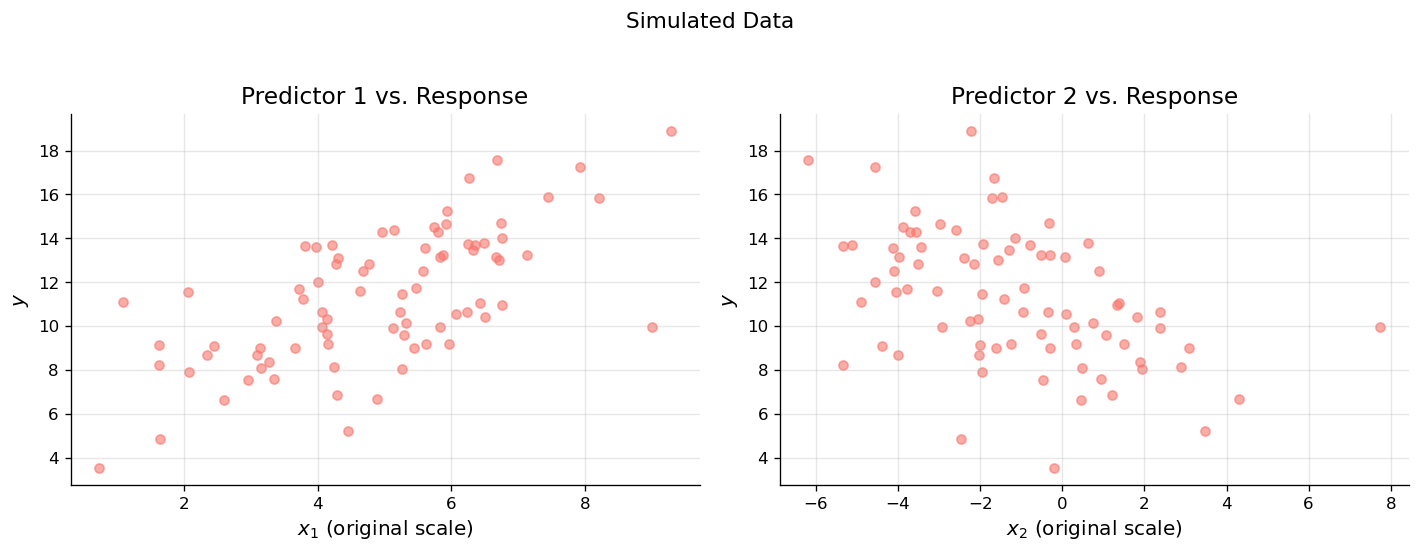

In [ ]:
# Quick scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for j, ax in enumerate(axes):
    ax.scatter(X_raw[:, j], y, s=30, alpha=0.6)
    ax.set_xlabel(f"$x_{j + 1}$ (original scale)")
    ax.set_ylabel("$y$")
    ax.set_title(f"Predictor {j + 1} vs. Response")
plt.suptitle("Simulated Data", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 2: Specify the PyMC model

PyMC uses a context-manager syntax.  Inside `with pm.Model() as ...`, every `pm.Normal(...)`, `pm.HalfNormal(...)`, etc. is registered as part of the model's probabilistic graph.

Key PyMC idioms:
- `pm.Normal("name", mu=..., sigma=...)` — define a random variable with a Normal prior.
- `pm.HalfNormal("name", sigma=...)` — prior restricted to positive values.
- `pm.Deterministic("name", expression)` — track a derived quantity in the trace.
- `observed=...` — connect the likelihood to the observed data.
- `pm.sample(draws, tune, ...)` — run MCMC (NUTS by default).

In [4]:
if HAS_PYMC:
    with pm.Model() as bayes_reg:
        # ── Priors ──
        # Intercept: on the standardised scale, the intercept ≈ mean(y)
        alpha = pm.Normal("alpha", mu=y.mean(), sigma=10)

        # Slopes: weakly informative, centred at zero
        betas = pm.Normal("betas", mu=0, sigma=10, shape=2)

        # Noise: must be positive
        sigma = pm.HalfNormal("sigma", sigma=5)

        # ── Likelihood ──
        mu = alpha + pm.math.dot(X, betas)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    print(bayes_reg)
else:
    print("PyMC not available — skipping model specification.")

### Step 3: Sample from the posterior

PyMC's `pm.sample()` runs the **No-U-Turn Sampler (NUTS)**, an adaptive variant of Hamiltonian Monte Carlo.  It automatically tunes step sizes during the `tune` phase, then draws `draws` samples from the posterior.  By default it runs multiple chains in parallel for convergence diagnostics.

In [5]:
if HAS_PYMC:
    with bayes_reg:
        trace = pm.sample(2000, tune=1000, random_seed=42, progressbar=True)
    print("Sampling complete.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 117 seconds.


Sampling complete.


### Step 4: Examine the trace

The **trace** is the collection of posterior samples.  We use ArviZ to visualise and summarise it.

#### Trace plots

`az.plot_trace()` shows two things per parameter:
- **Left panel:** The marginal posterior density (a smoothed histogram of the MCMC samples).
- **Right panel:** The trace (sample values vs. iteration number).  A healthy trace looks like a "fuzzy caterpillar" — it should mix well, with no trends or stuck regions.

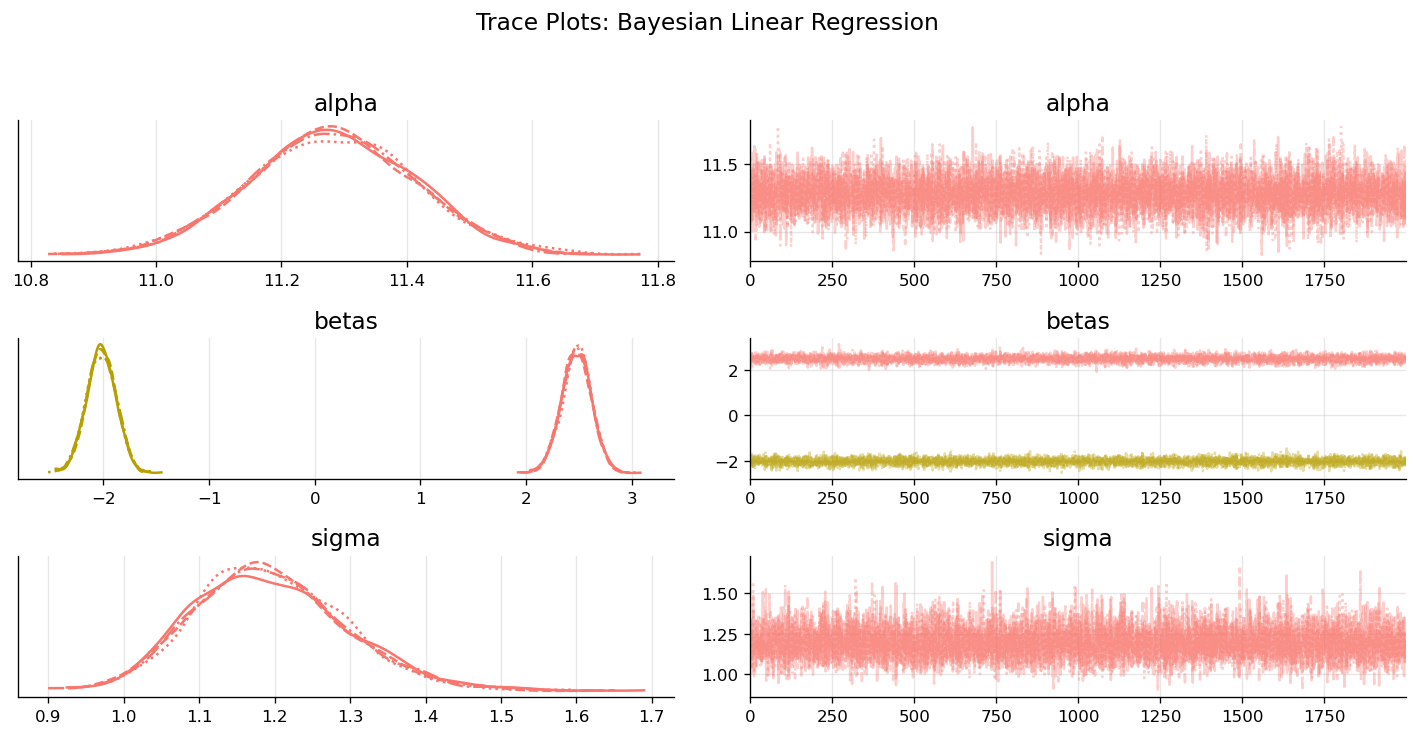

In [6]:
if HAS_PYMC:
    az.plot_trace(trace, var_names=["alpha", "betas", "sigma"])
    plt.suptitle("Trace Plots: Bayesian Linear Regression", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

The traces should look like stationary noise (good mixing), and the posterior densities should be unimodal and concentrated near the true parameter values.

#### Posterior summaries

`az.summary()` gives a table with the posterior mean, standard deviation, and the **94% HDI** (highest density interval) for each parameter.  It also reports convergence diagnostics:

- **$\hat{R}$** (R-hat): Should be close to 1.00.  Values above 1.01 indicate the chains have not converged.
- **ESS** (effective sample size): The number of effectively independent samples.  Should be at least a few hundred.

In [7]:
if HAS_PYMC:
    summary = az.summary(trace, var_names=["alpha", "betas", "sigma"], round_to=3)
    print(summary)
    print()

    # Compare to true values (on standardised scale)
    # On the standardised predictor scale:
    #   beta_std_j = beta_true_j * X_std_j
    #   alpha_std  = alpha_true + sum(beta_true_j * X_mean_j)
    beta_std_true = beta_true * X_std
    alpha_std_true = alpha_true + beta_true @ X_mean

    print(f"True parameters (standardised predictor scale):")
    print(f"  alpha  = {alpha_std_true:.3f}")
    print(f"  beta_1 = {beta_std_true[0]:.3f}")
    print(f"  beta_2 = {beta_std_true[1]:.3f}")
    print(f"  sigma  = {sigma_true:.3f}")

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
alpha     11.281  0.132  11.022   11.518      0.001    0.001  10784.571   
betas[0]   2.478  0.139   2.214    2.738      0.001    0.001   9642.502   
betas[1]  -2.021  0.139  -2.282   -1.766      0.001    0.001  10227.215   
sigma      1.193  0.100   1.018    1.385      0.001    0.001  11724.405   

          ess_tail  r_hat  
alpha     6204.515  1.001  
betas[0]  6859.320  1.000  
betas[1]  6755.069  1.000  
sigma     6339.626  1.001  

True parameters (standardised predictor scale):
  alpha  = 11.301
  beta_1 = 2.634
  beta_2 = -2.028
  sigma  = 1.200


#### Posterior density plots

`az.plot_posterior()` shows the marginal posterior for each parameter with the HDI shaded.  We can overlay the true values to check recovery.

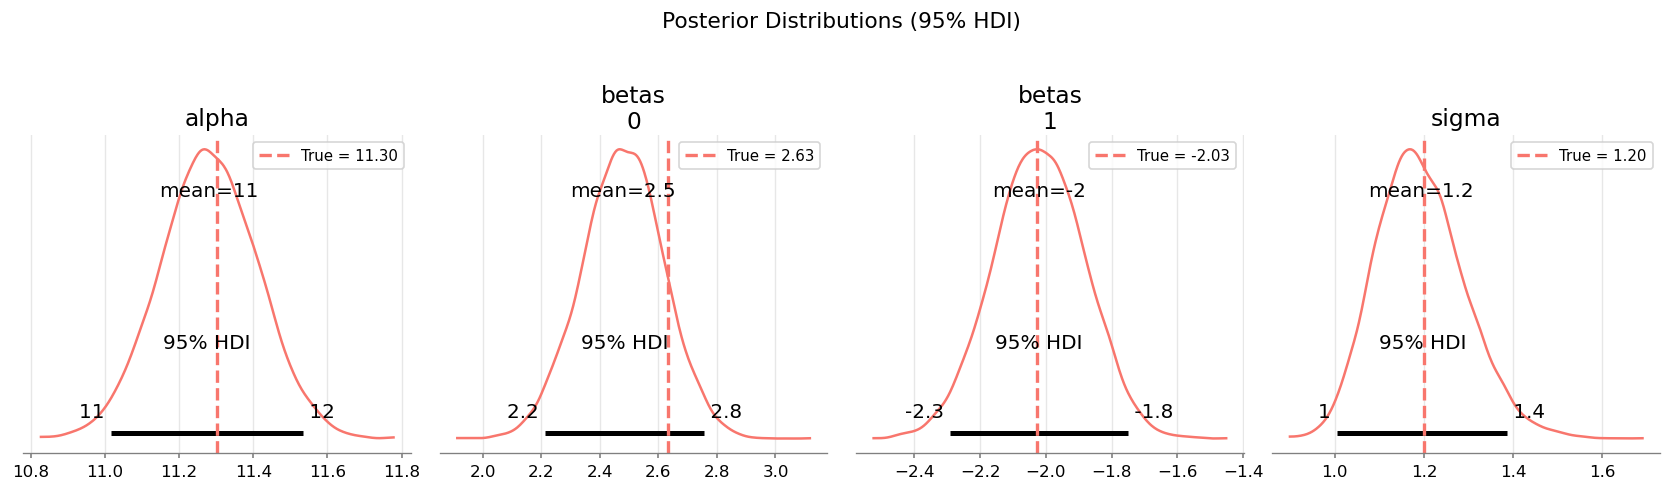

In [ ]:
if HAS_PYMC:
    axes_post = az.plot_posterior(
        trace,
        var_names=["alpha", "betas", "sigma"],
        hdi_prob=0.95,
        figsize=(14, 4),
    )

    # Overlay true values
    true_vals = [alpha_std_true, beta_std_true[0], beta_std_true[1], sigma_true]
    axes_flat = axes_post.flatten() if hasattr(axes_post, "flatten") else [axes_post]
    for ax, tv in zip(axes_flat, true_vals):
        ax.axvline(tv, color="#F8766D", ls="--", lw=2, label=f"True = {tv:.2f}")
        ax.legend(fontsize=9)

    plt.suptitle("Posterior Distributions (95% HDI)", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

The dashed red lines show the true parameter values.  With $n = 80$ observations and weakly informative priors, the posterior should concentrate tightly around the truth.  The 95% HDI for each parameter should contain the true value.

---

## 4. Manim Animation: Posterior Predictive Draws

This animation illustrates the core payoff of Bayesian regression: instead of a single "best fit" line, we get a **distribution of plausible lines**.  Each line is drawn from the posterior — each uses a different $(\alpha, \boldsymbol{\beta})$ sampled from the joint posterior distribution.

Where the data are dense, the lines cluster tightly (low uncertainty).  At the edges of the predictor range, they fan out (high uncertainty).  The spread of the lines *is* the posterior predictive uncertainty.

In [9]:
from manim import *

cfg.apply_manim_config()

Manim Community v0.18.1

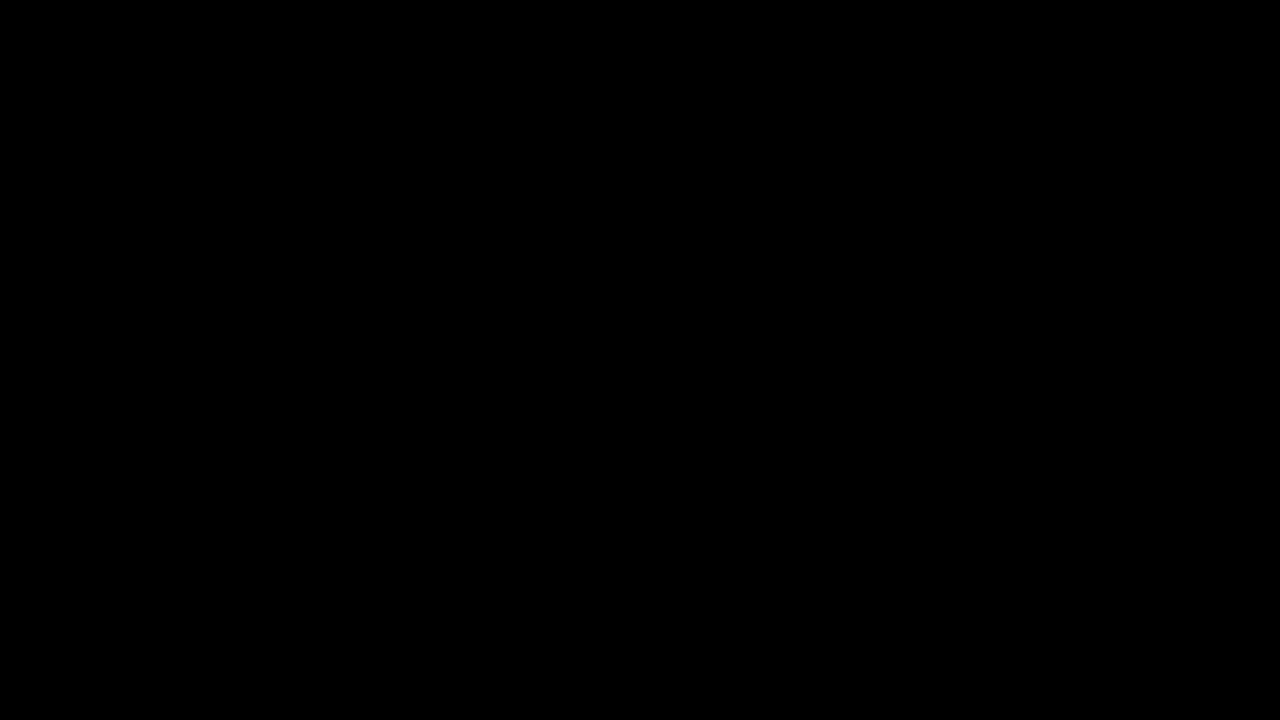

In [ ]:
%%manim -qm -v WARNING PosteriorPredictive

from amstats.manim_utils import C


class PosteriorPredictive(Scene):
    """Posterior predictive regression lines drawn from the posterior.

    Data points appear, then many semi-transparent regression lines are
    drawn — each from a different posterior sample of (intercept, slope).
    The lines fan out where data are sparse and converge where data are dense.
    Finally the posterior mean line is highlighted.
    """

    def construct(self):
        # ── Simulated 1-D data for visual clarity ──
        np.random.seed(99)
        n_pts = 35
        x_data = np.sort(np.random.uniform(1, 9, n_pts))
        y_data = 2.0 + 1.3 * x_data + np.random.normal(0, 1.5, n_pts)

        # OLS fit (used as posterior mean proxy for the animation)
        x_bar, y_bar = x_data.mean(), y_data.mean()
        S_xy = np.sum((x_data - x_bar) * (y_data - y_bar))
        S_xx = np.sum((x_data - x_bar) ** 2)
        b1_hat = S_xy / S_xx
        b0_hat = y_bar - b1_hat * x_bar

        # Approximate posterior samples (Normal around OLS, scaled by SE)
        resid = y_data - (b0_hat + b1_hat * x_data)
        s2 = np.sum(resid**2) / (n_pts - 2)
        se_b1 = np.sqrt(s2 / S_xx)
        se_b0 = np.sqrt(s2 * (1.0 / n_pts + x_bar**2 / S_xx))

        n_lines = 60
        rng_m = np.random.default_rng(7)
        b0_samples = rng_m.normal(b0_hat, se_b0, n_lines)
        b1_samples = rng_m.normal(b1_hat, se_b1, n_lines)

        # ── Axes ──
        axes = Axes(
            x_range=[0, 11, 2],
            y_range=[0, 18, 3],
            x_length=9.5,
            y_length=5.5,
            axis_config={"include_numbers": True, "font_size": 22},
        ).shift(DOWN * 0.2)
        x_lab = MathTex("x", font_size=28).next_to(axes.x_axis, RIGHT, buff=0.15)
        y_lab = MathTex("y", font_size=28).next_to(axes.y_axis, UP, buff=0.15)

        title = Text(
            "Posterior Predictive: Distribution of Plausible Lines",
            font_size=28,
            color=C.LABEL,
        ).to_edge(UP, buff=0.25)

        self.play(Create(axes), Write(x_lab), Write(y_lab), Write(title), run_time=1.2)

        # ── Data dots ──
        dots = VGroup(
            *[
                Dot(axes.c2p(xi, yi), radius=0.06, color=C.PERIWINKLE)
                for xi, yi in zip(x_data, y_data)
            ]
        )
        self.play(
            LaggedStart(*[FadeIn(d, scale=0.5) for d in dots], lag_ratio=0.04),
            run_time=1.5,
        )
        self.wait(0.5)

        # ── Draw posterior lines (batches for visual effect) ──
        x0_line, x1_line = 0.3, 10.7

        def make_post_line(b0, b1):
            ya = b0 + b1 * x0_line
            yb = b0 + b1 * x1_line
            # Clamp to axes
            ya = np.clip(ya, 0, 18)
            yb = np.clip(yb, 0, 18)
            return Line(
                axes.c2p(x0_line, ya),
                axes.c2p(x1_line, yb),
                color=C.SALMON,
                stroke_width=1.5,
                stroke_opacity=0.2,
            )

        # Label
        post_label = Text(
            "Each line = one posterior sample",
            font_size=22,
            color=C.SALMON,
        ).to_corner(UR, buff=0.4)
        self.play(Write(post_label), run_time=0.5)

        # Draw lines in batches of 10
        all_lines = VGroup()
        batch_size = 10
        for start in range(0, n_lines, batch_size):
            end = min(start + batch_size, n_lines)
            batch = VGroup(
                *[
                    make_post_line(b0_samples[k], b1_samples[k])
                    for k in range(start, end)
                ]
            )
            self.play(
                *[Create(line) for line in batch],
                run_time=0.5,
            )
            all_lines.add(*batch)

        self.wait(0.8)

        # ── Posterior mean line (highlighted) ──
        mean_line = Line(
            axes.c2p(x0_line, b0_hat + b1_hat * x0_line),
            axes.c2p(x1_line, b0_hat + b1_hat * x1_line),
            color=C.GOLD,
            stroke_width=3.5,
        )
        mean_label = Text(
            "Posterior mean",
            font_size=22,
            color=C.GOLD,
        ).next_to(post_label, DOWN, aligned_edge=LEFT, buff=0.25)

        self.play(Create(mean_line), Write(mean_label), run_time=0.8)

        # ── Annotation: uncertainty at edges ──
        arrow_left = Arrow(
            axes.c2p(1.0, 14),
            axes.c2p(1.0, 11),
            color=C.LABEL,
            stroke_width=2,
        )
        arrow_right = Arrow(
            axes.c2p(10.0, 16),
            axes.c2p(10.0, 13),
            color=C.LABEL,
            stroke_width=2,
        )
        spread_text = Text(
            "Lines spread at edges\n(more uncertainty)",
            font_size=18,
            color=C.LABEL,
        ).next_to(arrow_right, UP, buff=0.1)

        self.play(
            Create(arrow_left),
            Create(arrow_right),
            Write(spread_text),
            run_time=0.8,
        )
        self.wait(2.0)

Each salmon line represents one plausible regression line drawn from the posterior.  Near the centre of the data (around $\bar{x}$), the lines are tightly bundled — the data constrain the fit well there.  At the edges, where observations are sparse, the lines fan out.  The gold line is the posterior mean — analogous to the OLS fit, but now embedded in a cloud of uncertainty.

This is the visual payoff of Bayesian regression: **uncertainty is not a number attached to a single line; it is the distribution of lines itself.**

---

## 5. Prior Predictive Checks

Before fitting the model, we should ask: **do the priors produce sensible predictions?**  A prior predictive check generates fake datasets from the prior alone (ignoring the observed data).  If the prior predictive samples look absurd — e.g., predicting exam scores of $-10{,}000$ or $+50{,}000$ — then the priors are too vague and should be tightened.

This is a crucial step that many practitioners skip.  Bad priors can slow down MCMC sampling, produce misleading posteriors with small datasets, or make the model numerically unstable.

### Good priors

Sampling: [alpha, betas, sigma, y_obs]
# 2026-03-19 22:26:28,237 INFO pymc.sampling.forward forward.py:473 -- Sampling: [alpha, betas, sigma, y_obs]



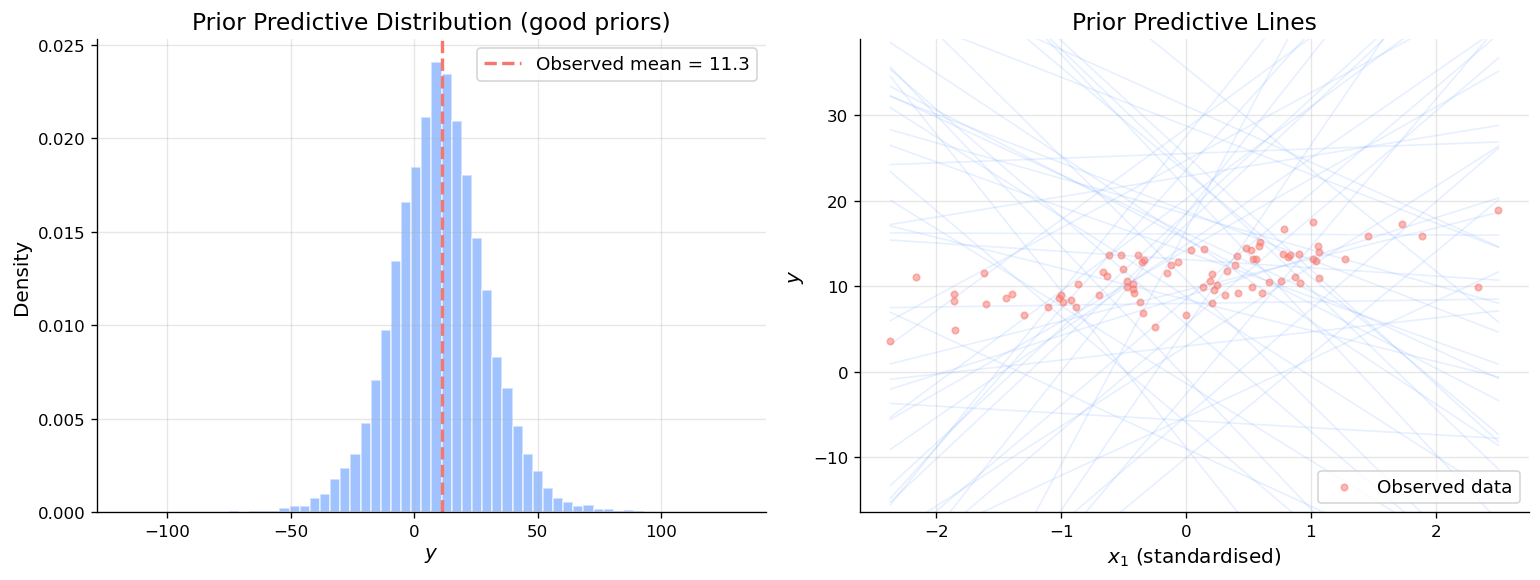

Prior predictive y: mean = 10.5, SD = 19.1
Observed y:         mean = 11.3, SD = 3.0

The prior predictive covers a wide range but the observed data
fall well within it. The priors are weakly informative — good.


In [ ]:
if HAS_PYMC:
    with bayes_reg:
        prior_pred = pm.sample_prior_predictive(samples=200, random_seed=42)

    # Plot prior predictive samples
    fig, axes_pp = plt.subplots(1, 2, figsize=(13, 5))

    # Left: histogram of prior predictive y values
    y_prior = prior_pred.prior_predictive["y_obs"].values.flatten()
    axes_pp[0].hist(
        y_prior, bins=60, density=True, alpha=0.6, color="#619CFF", edgecolor="white"
    )
    axes_pp[0].axvline(
        y.mean(),
        color="#F8766D",
        ls="--",
        lw=2,
        label=f"Observed mean = {y.mean():.1f}",
    )
    axes_pp[0].set_xlabel("$y$")
    axes_pp[0].set_ylabel("Density")
    axes_pp[0].set_title("Prior Predictive Distribution (good priors)")
    axes_pp[0].legend()

    # Right: prior predictive regression lines (using predictor 1)
    alpha_prior_samples = prior_pred.prior["alpha"].values.flatten()
    betas_prior_samples = prior_pred.prior["betas"].values  # shape: (chains, draws, 2)
    betas_prior_flat = betas_prior_samples.reshape(-1, 2)

    x_plot = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    for k in range(min(50, len(alpha_prior_samples))):
        y_line = alpha_prior_samples[k] + betas_prior_flat[k, 0] * x_plot
        axes_pp[1].plot(x_plot, y_line, color="#619CFF", alpha=0.15, lw=1)

    axes_pp[1].scatter(
        X[:, 0], y, s=15, color="#F8766D", alpha=0.5, zorder=5, label="Observed data"
    )
    axes_pp[1].set_xlabel("$x_1$ (standardised)")
    axes_pp[1].set_ylabel("$y$")
    axes_pp[1].set_title("Prior Predictive Lines")
    axes_pp[1].set_ylim(y.min() - 20, y.max() + 20)
    axes_pp[1].legend()

    plt.tight_layout()
    plt.show()

    print(f"Prior predictive y: mean = {y_prior.mean():.1f}, SD = {y_prior.std():.1f}")
    print(f"Observed y:         mean = {y.mean():.1f}, SD = {y.std():.1f}")
    print("\nThe prior predictive covers a wide range but the observed data")
    print("fall well within it. The priors are weakly informative — good.")

### Bad priors: what happens when priors are too wide

Let us see what happens if we use absurdly vague priors — say, $\alpha \sim \mathcal{N}(0, 1000)$ and $\beta_j \sim \mathcal{N}(0, 1000)$.

Sampling: [alpha, betas, sigma, y_obs]
# 2026-03-19 22:26:36,027 INFO pymc.sampling.forward forward.py:473 -- Sampling: [alpha, betas, sigma, y_obs]



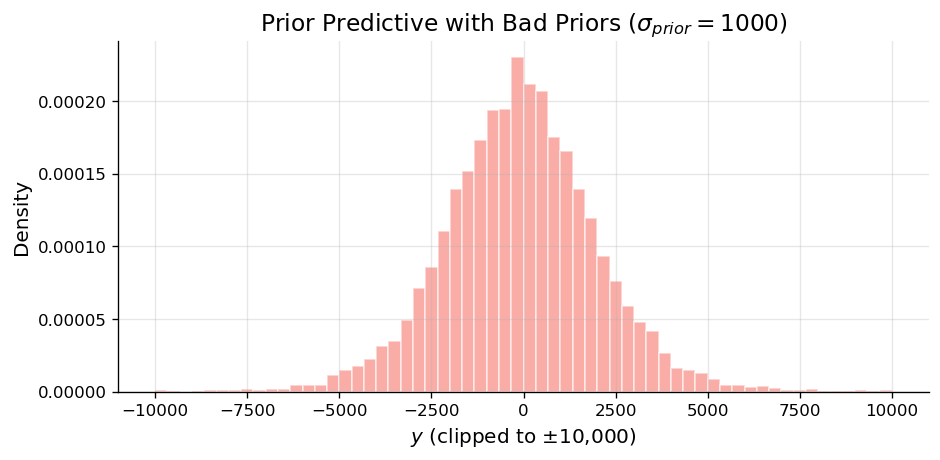

Prior predictive y (bad priors): mean = -73, SD = 2092
Observed y:                      mean = 11.3, SD = 3.0

The prior predicts values that are orders of magnitude larger than
anything we would ever observe. These priors are too vague.
With enough data, MCMC will still converge — but it will be slower
and less efficient. With small n, the posterior could be misleading.


In [ ]:
if HAS_PYMC:
    with pm.Model() as bad_prior_model:
        alpha_bad = pm.Normal("alpha", mu=0, sigma=1000)
        betas_bad = pm.Normal("betas", mu=0, sigma=1000, shape=2)
        sigma_bad = pm.HalfNormal("sigma", sigma=1000)
        mu_bad = alpha_bad + pm.math.dot(X, betas_bad)
        y_bad = pm.Normal("y_obs", mu=mu_bad, sigma=sigma_bad, observed=y)

        prior_bad = pm.sample_prior_predictive(samples=200, random_seed=42)

    y_prior_bad = prior_bad.prior_predictive["y_obs"].values.flatten()

    fig, ax = plt.subplots(figsize=(8, 4))
    # Clip for visualisation (values can be astronomically large)
    y_clipped = np.clip(y_prior_bad, -1e4, 1e4)
    ax.hist(
        y_clipped, bins=60, density=True, alpha=0.6, color="#F8766D", edgecolor="white"
    )
    ax.set_xlabel("$y$ (clipped to $\\pm 10{,}000$)")
    ax.set_ylabel("Density")
    ax.set_title("Prior Predictive with Bad Priors ($\\sigma_{prior} = 1000$)")
    plt.tight_layout()
    plt.show()

    print(
        f"Prior predictive y (bad priors): mean = {y_prior_bad.mean():.0f}, SD = {y_prior_bad.std():.0f}"
    )
    print(f"Observed y:                      mean = {y.mean():.1f}, SD = {y.std():.1f}")
    print("\nThe prior predicts values that are orders of magnitude larger than")
    print("anything we would ever observe. These priors are too vague.")
    print("With enough data, MCMC will still converge — but it will be slower")
    print("and less efficient. With small n, the posterior could be misleading.")

The lesson: **always do a prior predictive check.**  If the prior generates predictions that are physically impossible (negative heights, speeds faster than light, exam scores of a million), tighten the priors.  This is not "cheating" — it is encoding domain knowledge.

---

## 6. Posterior Predictive Checks

After fitting the model, we ask: **can the fitted model reproduce the observed data?**  We generate new datasets from the posterior predictive distribution:

$$y_{\text{rep}} \sim P(y_{\text{rep}} \mid \mathbf{y}) = \int P(y_{\text{rep}} \mid \theta) \, P(\theta \mid \mathbf{y}) \, d\theta$$

In practice, for each posterior sample $\theta^{(s)} = (\alpha^{(s)}, \boldsymbol{\beta}^{(s)}, \sigma^{(s)})$, we simulate a new dataset $\mathbf{y}_{\text{rep}}^{(s)}$.  If the model is good, the replicated data should look like the observed data.

`az.plot_ppc()` overlays the observed data distribution against many replicated distributions.

Sampling: [y_obs]
# 2026-03-19 22:26:48,531 INFO pymc.sampling.forward forward.py:917 -- Sampling: [y_obs]



Output()

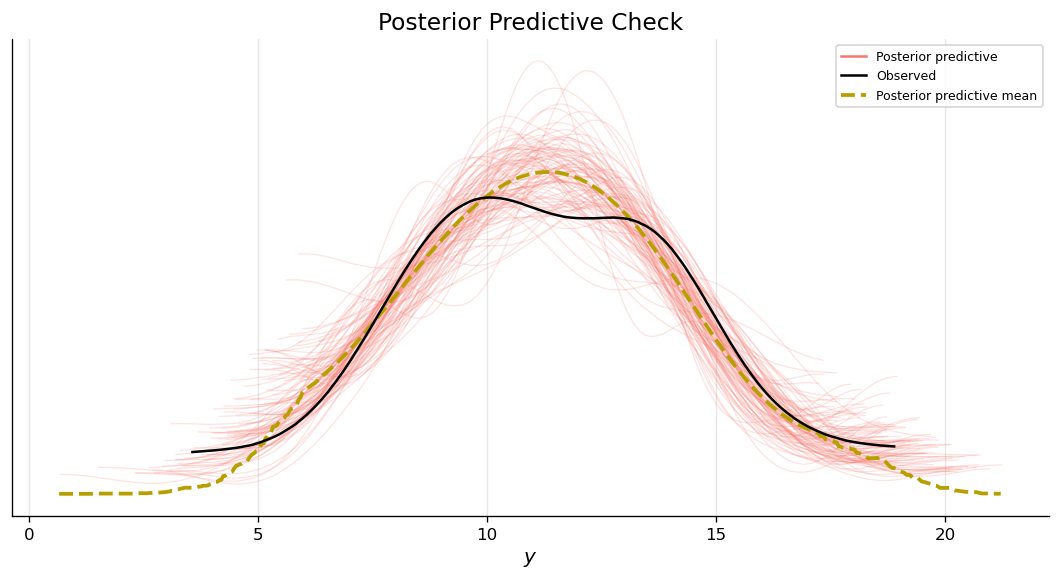

The dark line is the observed data distribution.
The light lines are replicated datasets from the posterior.
If they overlap well, the model captures the data-generating process.


In [13]:
if HAS_PYMC:
    with bayes_reg:
        post_pred = pm.sample_posterior_predictive(trace, random_seed=42)

    # Merge into the InferenceData object
    trace.extend(post_pred)

    fig, ax = plt.subplots(figsize=(9, 5))
    az.plot_ppc(trace, num_pp_samples=100, ax=ax)
    ax.set_title("Posterior Predictive Check")
    ax.set_xlabel("$y$")
    plt.tight_layout()
    plt.show()

    print("The dark line is the observed data distribution.")
    print("The light lines are replicated datasets from the posterior.")
    print("If they overlap well, the model captures the data-generating process.")

If the observed data density (dark line) falls well within the cloud of replicated densities (light lines), the model is a reasonable fit.  Systematic discrepancies — e.g., the model predicting too narrow a distribution, or missing skewness — indicate model misspecification.

---

## 7. Credible Intervals vs. Confidence Intervals

This is perhaps the most important conceptual difference between Bayesian and frequentist inference — and the reason many people prefer the Bayesian framework.

### Frequentist 95% confidence interval for $\beta_1$

Recall from Module 04:

$$\hat{\beta}_1 \pm t_{n-p-1, \, 0.025} \cdot \operatorname{SE}(\hat{\beta}_1)$$

**Interpretation:** If we repeated the experiment many times and computed this interval each time, **95% of the intervals** would contain the true $\beta_1$.  For *this particular* interval, $\beta_1$ is either in it or not — we cannot assign a probability.

This is technically correct but deeply unintuitive.  Students, scientists, and even statisticians routinely misinterpret confidence intervals as probability statements about parameters.

### Bayesian 95% credible interval (HDI) for $\beta_1$

The **highest density interval (HDI)** is the narrowest interval containing 95% of the posterior probability:

$$P\bigl(\beta_1 \in [a, b] \mid \mathbf{y}\bigr) = 0.95$$

**Interpretation:** Given the data we observed, there is a **95% probability** that $\beta_1$ lies in $[a, b]$.

This is the statement that students *wanted* the confidence interval to make.  It is a direct probability statement about the parameter, conditional on the observed data.

### Why the Bayesian interpretation works

In the Bayesian framework, $\beta_1$ is a random variable with a posterior distribution.  It makes perfect sense to compute $P(\beta_1 \in [a, b] \mid \mathbf{y})$.  In the frequentist framework, $\beta_1$ is a fixed constant — it does not have a probability distribution — so $P(\beta_1 \in [a, b])$ is either 0 or 1, and the notion of "95% probability" does not apply.

### When do they agree?

With weakly informative priors and moderate to large sample sizes, the 95% HDI and the 95% CI are numerically very similar.  This is a consequence of the **Bernstein-von Mises theorem**: as $n \to \infty$, the posterior converges to a Normal distribution centred at the MLE with variance equal to the inverse Fisher information — the same distribution that underlies the confidence interval.

They diverge when:
- The sample size is small
- The prior is informative
- The model is complex (hierarchical, non-Normal, etc.)

In [ ]:
if HAS_PYMC and HAS_SM:
    # ── Frequentist CIs ──
    X_sm = sm.add_constant(X)
    ols_fit = sm.OLS(y, X_sm).fit()
    freq_ci = ols_fit.conf_int(alpha=0.05)

    # ── Bayesian HDIs ──
    hdi = az.hdi(trace, var_names=["alpha", "betas"], hdi_prob=0.95)
    alpha_hdi = hdi["alpha"].values
    betas_hdi = hdi["betas"].values  # shape (2, 2)

    param_names = ["Intercept (alpha)", "beta_1", "beta_2"]

    print(f"{'Parameter':<22s}  {'Freq. 95% CI':>22s}  {'Bayes. 95% HDI':>22s}")
    print("-" * 70)

    # Intercept
    print(
        f"{param_names[0]:<22s}  [{freq_ci[0, 0]:8.3f}, {freq_ci[0, 1]:8.3f}]"
        f"  [{alpha_hdi[0]:8.3f}, {alpha_hdi[1]:8.3f}]"
    )
    # Slopes
    for j in range(2):
        print(
            f"{param_names[j + 1]:<22s}  [{freq_ci[j + 1, 0]:8.3f}, {freq_ci[j + 1, 1]:8.3f}]"
            f"  [{betas_hdi[j, 0]:8.3f}, {betas_hdi[j, 1]:8.3f}]"
        )

    print(
        "\nWith weakly informative priors and n = 80, the two intervals are very similar."
    )
    print("But the INTERPRETATIONS are fundamentally different.")

Parameter                         Freq. 95% CI          Bayes. 95% HDI
----------------------------------------------------------------------
Intercept (alpha)       [  11.018,   11.541]  [  11.018,   11.534]
beta_1                  [   2.211,    2.752]  [   2.212,    2.756]
beta_2                  [  -2.295,   -1.754]  [  -2.291,   -1.752]

With weakly informative priors and n = 80, the two intervals are very similar.
But the INTERPRETATIONS are fundamentally different.


---

## 8. Comparison with OLS

Let us directly compare the Bayesian posterior means with the OLS point estimates.  With weakly informative priors and a decent sample size, they should be nearly identical.

In [ ]:
if HAS_PYMC and HAS_SM:
    # Extract posterior means
    post_summary = az.summary(trace, var_names=["alpha", "betas", "sigma"], round_to=4)
    bayes_alpha = post_summary.loc["alpha", "mean"]
    bayes_b1 = post_summary.loc["betas[0]", "mean"]
    bayes_b2 = post_summary.loc["betas[1]", "mean"]
    bayes_sigma = post_summary.loc["sigma", "mean"]

    # OLS estimates
    ols_alpha = ols_fit.params[0]
    ols_b1 = ols_fit.params[1]
    ols_b2 = ols_fit.params[2]
    ols_sigma = np.sqrt(ols_fit.mse_resid)

    print(f"{'Parameter':<12s}  {'OLS':>10s}  {'Bayes':>10s}  {'Difference':>12s}")
    print("-" * 50)
    for name, ov, bv in [
        ("alpha", ols_alpha, bayes_alpha),
        ("beta_1", ols_b1, bayes_b1),
        ("beta_2", ols_b2, bayes_b2),
        ("sigma", ols_sigma, bayes_sigma),
    ]:
        print(f"{name:<12s}  {ov:10.4f}  {bv:10.4f}  {abs(ov - bv):12.4f}")

    print(
        "\nWith weakly informative priors and n = 80, the estimates are nearly identical."
    )
    print("Bayesian regression subsumes OLS as a special case.")

Parameter            OLS       Bayes    Difference
--------------------------------------------------
alpha            11.2792     11.2812        0.0020
beta_1            2.4816      2.4780        0.0036
beta_2           -2.0243     -2.0208        0.0035
sigma             1.1740      1.1934        0.0194

With weakly informative priors and n = 80, the estimates are nearly identical.
Bayesian regression subsumes OLS as a special case.


### When do Bayesian and OLS estimates diverge?

The estimates diverge in three main situations:

1. **Small sample size.** With few observations, the prior has more influence. The posterior mean is pulled toward the prior mean ("shrinkage").

2. **Informative priors.** If the prior strongly favours certain parameter values, the posterior will be a compromise between prior and likelihood.

3. **Non-Normal data or complex models.** OLS assumes Normal errors. If the data are heavy-tailed, skewed, or have outliers, OLS estimates can be distorted. Bayesian models with robust likelihoods (e.g., Student-$t$ errors) handle this more gracefully.

Let us demonstrate the small-$n$ case.

In [ ]:
if HAS_PYMC and HAS_SM:
    # ── Small-n experiment ──
    n_small = 8
    X_small = X[:n_small]
    y_small = y[:n_small]

    # OLS on small data
    X_sm_small = sm.add_constant(X_small)
    ols_small = sm.OLS(y_small, X_sm_small).fit()

    # Bayesian with mildly informative prior (centred at zero, sd=2)
    with pm.Model() as small_model:
        alpha_s = pm.Normal("alpha", mu=y_small.mean(), sigma=5)
        betas_s = pm.Normal("betas", mu=0, sigma=2, shape=2)  # informative!
        sigma_s = pm.HalfNormal("sigma", sigma=3)
        mu_s = alpha_s + pm.math.dot(X_small, betas_s)
        y_s = pm.Normal("y_obs", mu=mu_s, sigma=sigma_s, observed=y_small)
        trace_small = pm.sample(2000, tune=1000, random_seed=42, progressbar=False)

    summary_small = az.summary(
        trace_small, var_names=["alpha", "betas", "sigma"], round_to=3
    )

    print(f"n = {n_small}, informative prior: beta_j ~ N(0, 2)")
    print(f"")
    print(f"{'Parameter':<12s}  {'OLS':>10s}  {'Bayes':>10s}  {'Shrinkage':>10s}")
    print("-" * 45)
    for name, idx_ols, idx_bayes in [
        ("alpha", 0, "alpha"),
        ("beta_1", 1, "betas[0]"),
        ("beta_2", 2, "betas[1]"),
    ]:
        ov = ols_small.params[idx_ols]
        bv = summary_small.loc[idx_bayes, "mean"]
        print(f"{name:<12s}  {ov:10.3f}  {bv:10.3f}  {abs(ov) - abs(bv):10.3f}")

    print("\nWith small n and informative priors, the Bayesian estimates are")
    print("'shrunk' toward the prior mean (zero for the slopes). This is")
    print("regularisation — it reduces overfitting when data are scarce.")

Initializing NUTS using jitter+adapt_diag...
# 2026-03-19 22:30:25,364 INFO pymc.sampling.mcmc mcmc.py:1659 -- Initializing NUTS using jitter+adapt_diag...

Multiprocess sampling (4 chains in 4 jobs)
# 2026-03-19 22:30:25,967 INFO pymc.sampling.mcmc mcmc.py:959 -- Multiprocess sampling (4 chains in 4 jobs)

NUTS: [alpha, betas, sigma]
# 2026-03-19 22:30:25,969 INFO pymc.sampling.mcmc mcmc.py:314 -- NUTS: [alpha, betas, sigma]

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 47 seconds.
# 2026-03-19 22:31:12,497 INFO pymc.sampling.mcmc mcmc.py:1142 -- Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 47 seconds.

There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
# 2026-03-19 22:31:12,547 ERROR pymc.stats.convergence convergence.py:187 -- There were 3 divergences after tuning. Increase `target_accept` or reparameterize.



n = 8, informative prior: beta_j ~ N(0, 2)

Parameter            OLS       Bayes   Shrinkage
---------------------------------------------
alpha             11.644      11.698      -0.054
beta_1             1.403       1.238       0.165
beta_2            -1.846      -1.699       0.147

With small n and informative priors, the Bayesian estimates are
'shrunk' toward the prior mean (zero for the slopes). This is
regularisation — it reduces overfitting when data are scarce.


The shrinkage effect is a feature, not a bug.  With only 8 observations and 2 predictors, OLS estimates are highly variable and prone to overfitting.  The Bayesian prior acts as a regulariser, pulling extreme estimates back toward zero.  This is mathematically equivalent to **ridge regression** when the prior on $\boldsymbol{\beta}$ is $\mathcal{N}(0, \sigma_\beta^2 I)$.

As $n$ grows, the likelihood dominates the prior and the Bayesian estimates converge to OLS.  The prior becomes irrelevant — the data speak for themselves.

---

## 9. Visualising the Posterior Predictive Distribution

The posterior predictive distribution gives us uncertainty bands around our predictions.  For each new $x^*$, we compute:

$$P(y^* \mid x^*, \mathbf{y}) = \int P(y^* \mid x^*, \theta) \, P(\theta \mid \mathbf{y}) \, d\theta$$

In practice: for each posterior sample $(\alpha^{(s)}, \boldsymbol{\beta}^{(s)}, \sigma^{(s)})$, compute the predicted mean and sample a new $y^*$ from $\mathcal{N}(\mu^{(s)}, (\sigma^{(s)})^2)$.  The distribution of these $y^*$ values incorporates both **parameter uncertainty** and **observation noise**.

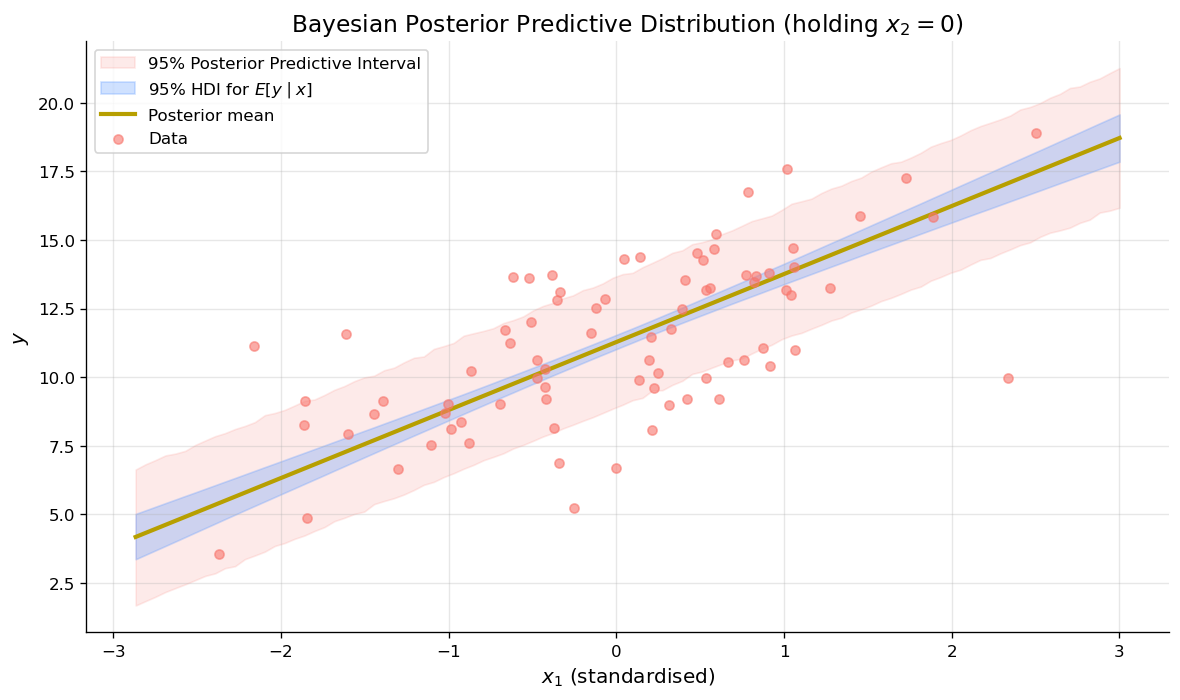

Blue band: uncertainty about the regression LINE (where E[y|x] could be).
Salmon band: uncertainty about INDIVIDUAL observations (includes noise).
This is the Bayesian analogue of the CI/PI distinction from Module 06.


In [ ]:
if HAS_PYMC:
    # Extract posterior samples
    post = az.extract(trace, var_names=["alpha", "betas", "sigma"])
    alpha_samples = post["alpha"].values
    beta_samples = post["betas"].values  # shape (2, n_samples)
    sigma_samples = post["sigma"].values
    n_samp = len(alpha_samples)

    # Prediction grid (vary x1, hold x2 at its mean = 0)
    x1_grid = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 100)
    x2_fixed = 0.0  # mean of standardised x2

    # Compute posterior predictive mean and bands
    # mu(x1) = alpha + beta_1 * x1 + beta_2 * 0 = alpha + beta_1 * x1
    mu_grid = alpha_samples[None, :] + beta_samples[0, :][None, :] * x1_grid[:, None]
    # shape: (100, n_samp)

    # Mean of the mean (posterior mean line)
    mu_mean = mu_grid.mean(axis=1)

    # 95% HDI of the mean (parameter uncertainty only)
    mu_lower = np.percentile(mu_grid, 2.5, axis=1)
    mu_upper = np.percentile(mu_grid, 97.5, axis=1)

    # 95% prediction interval (parameter uncertainty + noise)
    y_rep = mu_grid + rng.normal(0, 1, mu_grid.shape) * sigma_samples[None, :]
    pred_lower = np.percentile(y_rep, 2.5, axis=1)
    pred_upper = np.percentile(y_rep, 97.5, axis=1)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Prediction interval
    ax.fill_between(
        x1_grid,
        pred_lower,
        pred_upper,
        color="#F8766D",
        alpha=0.15,
        label="95% Posterior Predictive Interval",
    )

    # Credible interval for the mean
    ax.fill_between(
        x1_grid,
        mu_lower,
        mu_upper,
        color="#619CFF",
        alpha=0.3,
        label="95% HDI for $E[y \\mid x]$",
    )

    # Posterior mean line
    ax.plot(x1_grid, mu_mean, color="#B79F00", lw=2.5, label="Posterior mean")

    # Data
    ax.scatter(X[:, 0], y, s=30, alpha=0.6, zorder=5, label="Data")

    ax.set_xlabel("$x_1$ (standardised)")
    ax.set_ylabel("$y$")
    ax.set_title("Bayesian Posterior Predictive Distribution (holding $x_2 = 0$)")
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print("Blue band: uncertainty about the regression LINE (where E[y|x] could be).")
    print("Salmon band: uncertainty about INDIVIDUAL observations (includes noise).")
    print("This is the Bayesian analogue of the CI/PI distinction from Module 06.")

Compare this to the frequentist confidence/prediction interval plot from Module 06.  The shapes are similar, but the interpretation is genuinely different: the Bayesian bands are direct probability statements, while the frequentist bands are coverage guarantees over hypothetical repetitions.

---

## Exercises

**Exercise 1 (Prior sensitivity).** Using the simulated data from Section 3, fit three Bayesian models with different priors on the slopes:

- (a) Very weakly informative: $\beta_j \sim \mathcal{N}(0, 100)$
- (b) Moderately informative: $\beta_j \sim \mathcal{N}(0, 2)$
- (c) Strongly informative and wrong: $\beta_j \sim \mathcal{N}(-5, 0.5)$

For each, report the posterior means and 95% HDIs for $\beta_1$ and $\beta_2$.  Plot all three posteriors on the same figure.  At what point does the prior dominate the data?  How many observations would you need to overcome prior (c)?

**Exercise 2 (Prior predictive thinking).** You are modelling house prices (in thousands of dollars) as a function of square footage (in hundreds of sqft).  A typical house is 1500 sqft and costs \$300k.

- (a) What prior would you set for the intercept $\alpha$?  What does $\alpha$ mean when sqft $= 0$?  Should you centre the predictor?
- (b) What prior would you set for $\beta$ (price change per 100 sqft)?  What range is reasonable?
- (c) Run `pm.sample_prior_predictive()` with your chosen priors and verify that the prior predictive samples look reasonable.

**Exercise 3 (Posterior predictive checking).** Simulate $n = 100$ data points from $y = 2 + 0.5 x + 0.05 x^2 + \varepsilon$ where $\varepsilon \sim \mathcal{N}(0, 1)$ and $x \sim \text{Uniform}(0, 10)$.  Fit a *linear* Bayesian model (no $x^2$ term).  Perform a posterior predictive check.  Does the PPC reveal the model misspecification?  What pattern do you see?

**Exercise 4 (Credible vs. confidence intervals).** Using the full $n = 80$ dataset:

- (a) Compute the Bayesian 90% HDI for $\beta_1$ and the frequentist 90% CI.
- (b) Now repeat with $n = 10$ (first 10 observations) and moderately informative priors.  How much do the intervals differ?
- (c) Compute $P(\beta_1 > 0 \mid \text{data})$ from the posterior.  What is the frequentist analogue of this quantity?  (Hint: think about one-sided p-values.)

**Exercise 5 (Bayesian R-squared).** The classical $R^2$ has no uncertainty — it is a single number.  The Bayesian $R^2$ proposed by Gelman et al. (2019) is:

$$R^2_{\text{Bayes}} = \frac{\operatorname{Var}(\hat{y})}{\operatorname{Var}(\hat{y}) + \sigma^2}$$

computed for each posterior sample, giving a *distribution* of $R^2$ values.

- (a) Compute the Bayesian $R^2$ distribution from the posterior samples.
- (b) Plot the distribution and report its mean and 95% HDI.
- (c) Compare the mean Bayesian $R^2$ to the classical $R^2$ from OLS.  Why might they differ?

---

## Key Takeaways

1. **Bayesian regression gives full posterior distributions** over $\alpha$, $\boldsymbol{\beta}$, and $\sigma$, rather than just point estimates and standard errors.  Every summary you want — means, intervals, probabilities — is derived from the posterior.

2. **The Bayesian linear model** is: $y_i \sim \mathcal{N}(\alpha + \mathbf{x}_i^\top \boldsymbol{\beta}, \sigma^2)$ with priors on $\alpha$, $\boldsymbol{\beta}$, and $\sigma$.  Prior choice matters; use **prior predictive checks** to verify priors generate plausible predictions.

3. **Posterior predictive checks** answer "can the fitted model reproduce the observed data?"  They are the Bayesian analogue of residual analysis.

4. **Credible intervals** have the interpretation that students *want*: "95% probability $\beta_1$ is in this interval."  This is a direct probability statement, unlike the frequentist confidence interval.

5. **With weakly informative priors and moderate $n$**, Bayesian posterior means closely match OLS estimates.  They diverge with small $n$, informative priors, or non-Normal data — and in those cases, the Bayesian estimates are generally better (less overfitting, more robust).

6. **PyMC** makes Bayesian regression practical: define priors, specify the likelihood, call `pm.sample()`, and use ArviZ for diagnostics and summaries.

7. **The Normal prior on slopes acts as ridge regularisation** — it shrinks extreme estimates toward zero, which is beneficial when data are scarce.

**Next:** [02_bayesian_logistic_regression.ipynb](02_bayesian_logistic_regression.ipynb) — extending the Bayesian framework to binary outcomes with logistic regression.

In [20]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/PosteriorPredictive@2026-03-19@22-26-01.gif
  ✓ media/gifs/PosteriorPredictive_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
